In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Load the Data
exoplanets = pd.read_csv("/content/drive/My Drive/Colab Notebooks/exoplanets_discovered.csv", sep=',')

In [ ]:
exoplanets

,discoverymethod,disc_year
0,Radial Velocity,2007
1,Radial Velocity,2009
2,Radial Velocity,2008
3,Radial Velocity,2002
4,Radial Velocity,1996
...,...,...
4296,Radial Velocity,2013
4297,Radial Velocity,1996
4298,Radial Velocity,1999
4299,Radial Velocity,1999


In [ ]:
# List of discovery types
x = np.array(exoplanets["discoverymethod"])
discovery_types = np.unique(x)

In [ ]:
discovery_types

array(['Astrometry', 'Disk Kinematics', 'Eclipse Timing Variations',
       'Imaging', 'Microlensing', 'Orbital Brightness Modulation',
       'Pulsar Timing', 'Pulsation Timing Variations', 'Radial Velocity',
       'Transit', 'Transit Timing Variations'], dtype=object)

In [ ]:
# List of years
year_start = min(exoplanets["disc_year"])
year_end = max(exoplanets["disc_year"])
print(year_start, " - ", year_end)

1989  -  2020


In [ ]:
# Make array of years and types
exoplanets_years = pd.DataFrame()
for year in range(year_start, year_end+1):
  discovery_type_list = []
  for index, discovery_type in enumerate(discovery_types):
    numPlanets = 0
    if year > year_start:
      # numplanets is the cumulative total.
      numPlanets = exoplanets_years.at[index,year-1]
    numPlanets += pd.Series.sum((exoplanets['disc_year'] == year) & (exoplanets['discoverymethod'] == discovery_type))
    discovery_type_list.append(numPlanets)
  exoplanets_years[year] = discovery_type_list
exoplanets_years.insert(0, "Discovery Type", discovery_types)


In [ ]:
exoplanets_years

,Discovery Type,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Astrometry,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1
1,Disk Kinematics,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
2,Eclipse Timing Variations,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,3,8,10,10,10,11,11,13,14,16,16
3,Imaging,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,4,8,9,16,17,23,25,27,34,36,41,43,44,45,49,51
4,Microlensing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,3,4,4,8,10,12,13,20,25,30,34,44,53,74,88,105
5,Orbital Brightness Modulation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,3,6,6,6,6,6,6,6
6,Pulsar Timing,0,0,0,2,2,3,3,3,3,3,3,3,3,3,4,4,4,4,4,4,4,4,5,5,5,5,5,5,7,7,7,7
7,Pulsation Timing Variations,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,2,2,2,2,2
8,Radial Velocity,1,1,1,1,1,1,2,8,9,15,28,44,56,84,105,123,156,177,211,249,322,363,410,444,476,526,573,622,671,721,789,821
9,Transit,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,6,6,11,27,44,62,108,187,280,359,1157,1257,2699,2788,3029,3137,3270


In [ ]:
exoplanets_years.to_csv(index=False)

'Discovery Type,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020\nAstrometry,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1\nDisk Kinematics,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1\nEclipse Timing Variations,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,3,8,10,10,10,11,11,13,14,16,16\nImaging,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,4,8,9,16,17,23,25,27,34,36,41,43,44,45,49,51\nMicrolensing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,3,4,4,8,10,12,13,20,25,30,34,44,53,74,88,105\nOrbital Brightness Modulation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,3,6,6,6,6,6,6,6\nPulsar Timing,0,0,0,2,2,3,3,3,3,3,3,3,3,3,4,4,4,4,4,4,4,4,5,5,5,5,5,5,7,7,7,7\nPulsation Timing Variations,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,2,2,2,2,2\nRadial Velocity,1,1,1,1,1,1,2,8,9,15,28,44,56,84,105,123,156,177,211,249,322,363,410,444,476,526,573,622,671,721,789,821\n

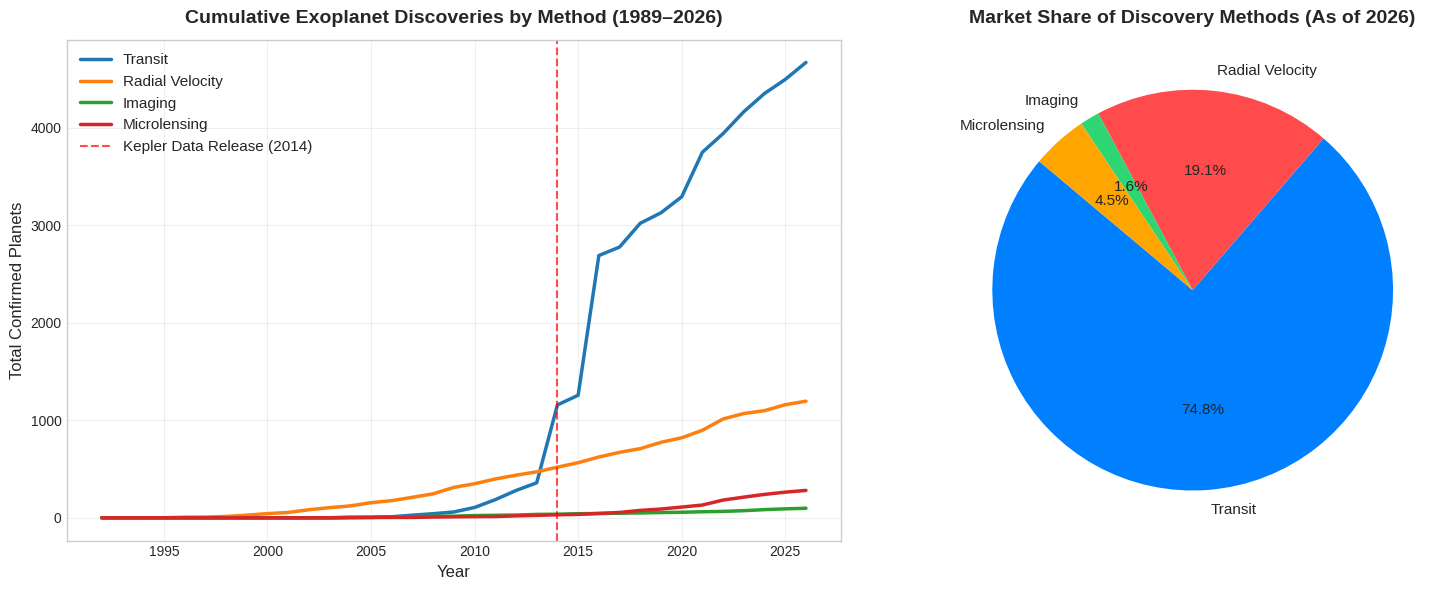

--- KEY SUMMARY STATISTICS ---
Total Confirmed Exoplanets Tracked: 6324
Transit Method Discoveries: 4667 (73.8%)
Radial Velocity Discoveries: 1195 (18.9%)


In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Set clean visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# Chart 1: Cumulative Growth of Discovery Methods Over Time
# ---------------------------------------------------------
# Transpose data so years are rows for plotting
df_plot = exoplanets_years.set_index('Discovery Type').T
df_plot.index = df_plot.index.astype(int)

# Plot top discovery methods
top_methods = ['Transit', 'Radial Velocity', 'Imaging', 'Microlensing']
for method in top_methods:
    if method in df_plot.columns:
        ax1.plot(df_plot.index, df_plot[method], label=method, linewidth=2.5)

ax1.set_title('Cumulative Exoplanet Discoveries by Method (1989–2026)', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Total Confirmed Planets', fontsize=12)
ax1.axvline(x=2014, color='red', linestyle='--', alpha=0.7, label='Kepler Data Release (2014)')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# ---------------------------------------------------------
# Chart 2: Share of Total Discoveries (Radial Velocity vs Transit)
# ---------------------------------------------------------
latest_year = df_plot.index.max()
latest_totals = df_plot.loc[latest_year, top_methods]

colors = ['#0080ff', '#ff4b4b', '#2ed573', '#ffa500']
ax2.pie(latest_totals, labels=latest_totals.index, autopct='%1.1f%%', startangle=140, colors=colors, textprops={'fontsize': 11})
ax2.set_title(f'Market Share of Discovery Methods (As of {latest_year})', fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

# Print summary metrics
total_planets = df_plot.loc[latest_year].sum()
transit_count = df_plot.loc[latest_year, 'Transit'] if 'Transit' in df_plot.columns else 0
rv_count = df_plot.loc[latest_year, 'Radial Velocity'] if 'Radial Velocity' in df_plot.columns else 0

print(f"--- KEY SUMMARY STATISTICS ---")
print(f"Total Confirmed Exoplanets Tracked: {int(total_planets)}")
print(f"Transit Method Discoveries: {int(transit_count)} ({transit_count/total_planets*100:.1f}%)")
print(f"Radial Velocity Discoveries: {int(rv_count)} ({rv_count/total_planets*100:.1f}%)")